In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (14, 8)

In [2]:
def load_results(results_folder):
    result_files = [f for f in os.listdir(results_folder) if f.endswith('.json')]
    results = {}
    
    for file in result_files:
        file_path = os.path.join(results_folder, file)
        with open(file_path, 'r') as f:
            results[file] = json.load(f)
    
    return results

In [3]:
def extract_detailed_node_metrics(results, experiment_name):
    """Extract detailed node metrics including platform results"""
    node_data = []
    platform_data = []
    storage_data = []

    for result_file, result in results.items():
        if 'nodeResults' in result['stats']:
            for node in result['stats']['nodeResults']:
                # Basic node metrics
                node_metrics = {
                    'experiment': experiment_name,
                    'file': result_file,
                    'node_id': node['nodeId'],
                    'unused': node.get('unused', False),
                    'scheduling_time': node.get('schedulingTime', 0),
                    'storage_time': node.get('storageTime', 0),
                    'local_dependencies': node.get('localDependencies', 0),
                    'cache_hits': node.get('cacheHits', 0),
                }

                # Energy metrics by platform type
                if 'energy' in node:
                    for platform_type, energy in node['energy'].items():
                        node_metrics[f'energy_{platform_type}'] = energy

                # Idle energy metrics
                if 'energyIdle' in node:
                    for platform_type, energy in node['energyIdle'].items():
                        node_metrics[f'idle_energy_{platform_type}'] = energy

                # Idle time metrics
                if 'idleTime' in node:
                    for platform_type, time_val in node['idleTime'].items():
                        node_metrics[f'idle_time_{platform_type}'] = time_val

                node_data.append(node_metrics)

                # Platform detailed metrics
                if 'platformResults' in node:
                    for platform in node['platformResults']:
                        platform_metrics = {
                            'experiment': experiment_name,
                            'file': result_file,
                            'node_id': node['nodeId'],
                            'platform_id': platform['platformId'],
                            'platform_type': platform['platformType']['shortName'],
                            'platform_hardware': platform['platformType']['hardware'],
                            'platform_price': platform['platformType']['price'],
                            'energy': platform.get('energy', 0),
                            'energy_idle': platform.get('energyIdle', 0),
                            'idle_time': platform.get('idleTime', 0),
                            'idle_proportion': platform.get('idleProportion', 0),
                            'storage_time': platform.get('storageTime', 0)
                        }
                        platform_data.append(platform_metrics)

                # todo: which are static and can serve as inputs, which are results of the simulation?
                # Storage metrics
                if 'storageResults' in node:
                    for storage in node['storageResults']:
                        storage_metrics = {
                            'experiment': experiment_name,
                            'file': result_file,
                            'node_id': node['nodeId'],
                            'storage_id': storage['storageId'],
                            'has_usage_data': len(storage.get('totalUsage', [])) > 0
                        }
                        storage_data.append(storage_metrics)

    return pd.DataFrame(node_data), pd.DataFrame(platform_data), pd.DataFrame(storage_data)

In [4]:
def extract_detailed_task_metrics(results, experiment_name):
    """Extract detailed task metrics"""
    tasks_data = []

    for result_file, result in results.items():
        if 'taskResults' in result['stats']:
            for task in result['stats']['taskResults']:
                task_data = {
                    'experiment': experiment_name,
                    'file': result_file,
                    'task_id': task['taskId'],
                    'dispatched_time': task['dispatchedTime'],
                    'scheduled_time': task['scheduledTime'],
                    'arrived_time': task['arrivedTime'],
                    'started_time': task['startedTime'],
                    'done_time': task['doneTime'],
                    'task_type': task['taskType']['name'],
                    'platform_type': task['platform']['shortName'],
                    'platform_hardware': task['platform']['hardware'],
                    'elapsed_time': task['elapsedTime'],
                    'pull_time': task.get('pullTime', 0),
                    'cold_start_time': task.get('coldStartTime', 0),
                    'execution_time': task.get('executionTime', 0),
                    'wait_time': task.get('waitTime', 0),
                    'queue_time': task.get('queueTime', 0),
                    'initialization_time': task.get('initializationTime', 0),
                    'compute_time': task.get('computeTime', 0),
                    'communications_time': task.get('communicationsTime', 0),
                    'cold_started': task.get('coldStarted', False),
                    'cache_hit': task.get('cacheHit', False),
                    'local_dependencies': task.get('localDependencies', False),
                    'local_communications': task.get('localCommunications', False),
                    'energy': task.get('energy', 0),
                    'network_latency': task['networkLatency'],
                    'source_node': task['sourceNode'],
                    'execution_node': task['executionNode'],
                    'execution_platform': task['executionPlatform'],
                }

                # Calculate task latency components
                task_data['scheduling_latency'] = task_data['scheduled_time'] - task_data['dispatched_time']
                task_data['arrival_latency'] = task_data['arrived_time'] - task_data['scheduled_time']
                task_data['start_latency'] = task_data['started_time'] - task_data['arrived_time']
                task_data['processing_latency'] = task_data['done_time'] - task_data['started_time']
                task_data['end_to_end_latency'] = task_data['done_time'] - task_data['dispatched_time']

                tasks_data.append(task_data)

    return pd.DataFrame(tasks_data)

In [5]:
import os
import pickle
import json
from collections import defaultdict
from tqdm import tqdm

def evaluate_json_file(file_path):
    """Evaluate if a JSON file is valid and can be parsed"""
    try:
        with open(file_path, 'r') as f:
            json.load(f)
        return True
    except json.JSONDecodeError as e:
        print(f"JSON decode error in {file_path}: {e}")
        return False
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return False

def load_experiment_data(experiments):
    experiment_data = {}

    for name, folder in experiments.items():
        # First evaluate JSON files in the folder
        if os.path.exists(folder):
            json_files = [f for f in os.listdir(folder) if f.endswith('.json')]
            print(f"Found {len(json_files)} JSON files in {folder}")
            
            # Check each JSON file
            valid_files = 0
            for json_file in json_files:
                file_path = os.path.join(folder, json_file)
                if evaluate_json_file(file_path):
                    valid_files += 1
                else:
                    print(f"Skipping invalid file: {json_file}")
            
            print(f"Valid JSON files: {valid_files}/{len(json_files)}")

        results = load_results(folder)
        node_df, platform_df, storage_df = extract_detailed_node_metrics(results, name)
        task_df = extract_detailed_task_metrics(results, name)
        experiment_data[name] = {
            "node_df": node_df,
            "platform_df": platform_df,
            "storage_df": storage_df,
            "task_df": task_df,
        }
    return experiment_data

In [6]:
experiments = {
    "knative": "/root/projects/my-herosim/src/notebooks/data/results_sim/125-225-5clients-knative-with-network",
    "wrr": "/root/projects/my-herosim/src/notebooks/data/results_sim/125-225-5clients-wrr-v1",
}
experiment_data = load_experiment_data(experiments)

results = experiment_data['wrr']
node_df = results['node_df']
plat_df = results['platform_df']
stor_df = results['storage_df']
task_df = results['task_df']

Found 2 JSON files in /root/projects/my-herosim/src/notebooks/data/results_sim/125-225-5clients-knative-with-network
Valid JSON files: 2/2
Found 1 JSON files in /root/projects/my-herosim/src/notebooks/data/results_sim/125-225-5clients-wrr-v1
Valid JSON files: 1/1


EXPERIMENT COMPARISON: LATENCY AND QUEUE TIME

1. LATENCY COMPARISON
----------------------------------------
             count        mean         std        min          max      median
experiment                                                                    
knative     411049  247.972388  184.206585  34.405745  1000.926922  201.565077
wrr         139336  265.640328  291.956002   0.045011  1079.901365  129.713059

2. QUEUE TIME COMPARISON
----------------------------------------
             count        mean         std        min          max      median
experiment                                                                    
knative     411049  247.901813  184.182645  34.360749  1000.740626  201.491826
wrr         139336  265.531639  291.901439   0.000000  1079.715041  129.623232


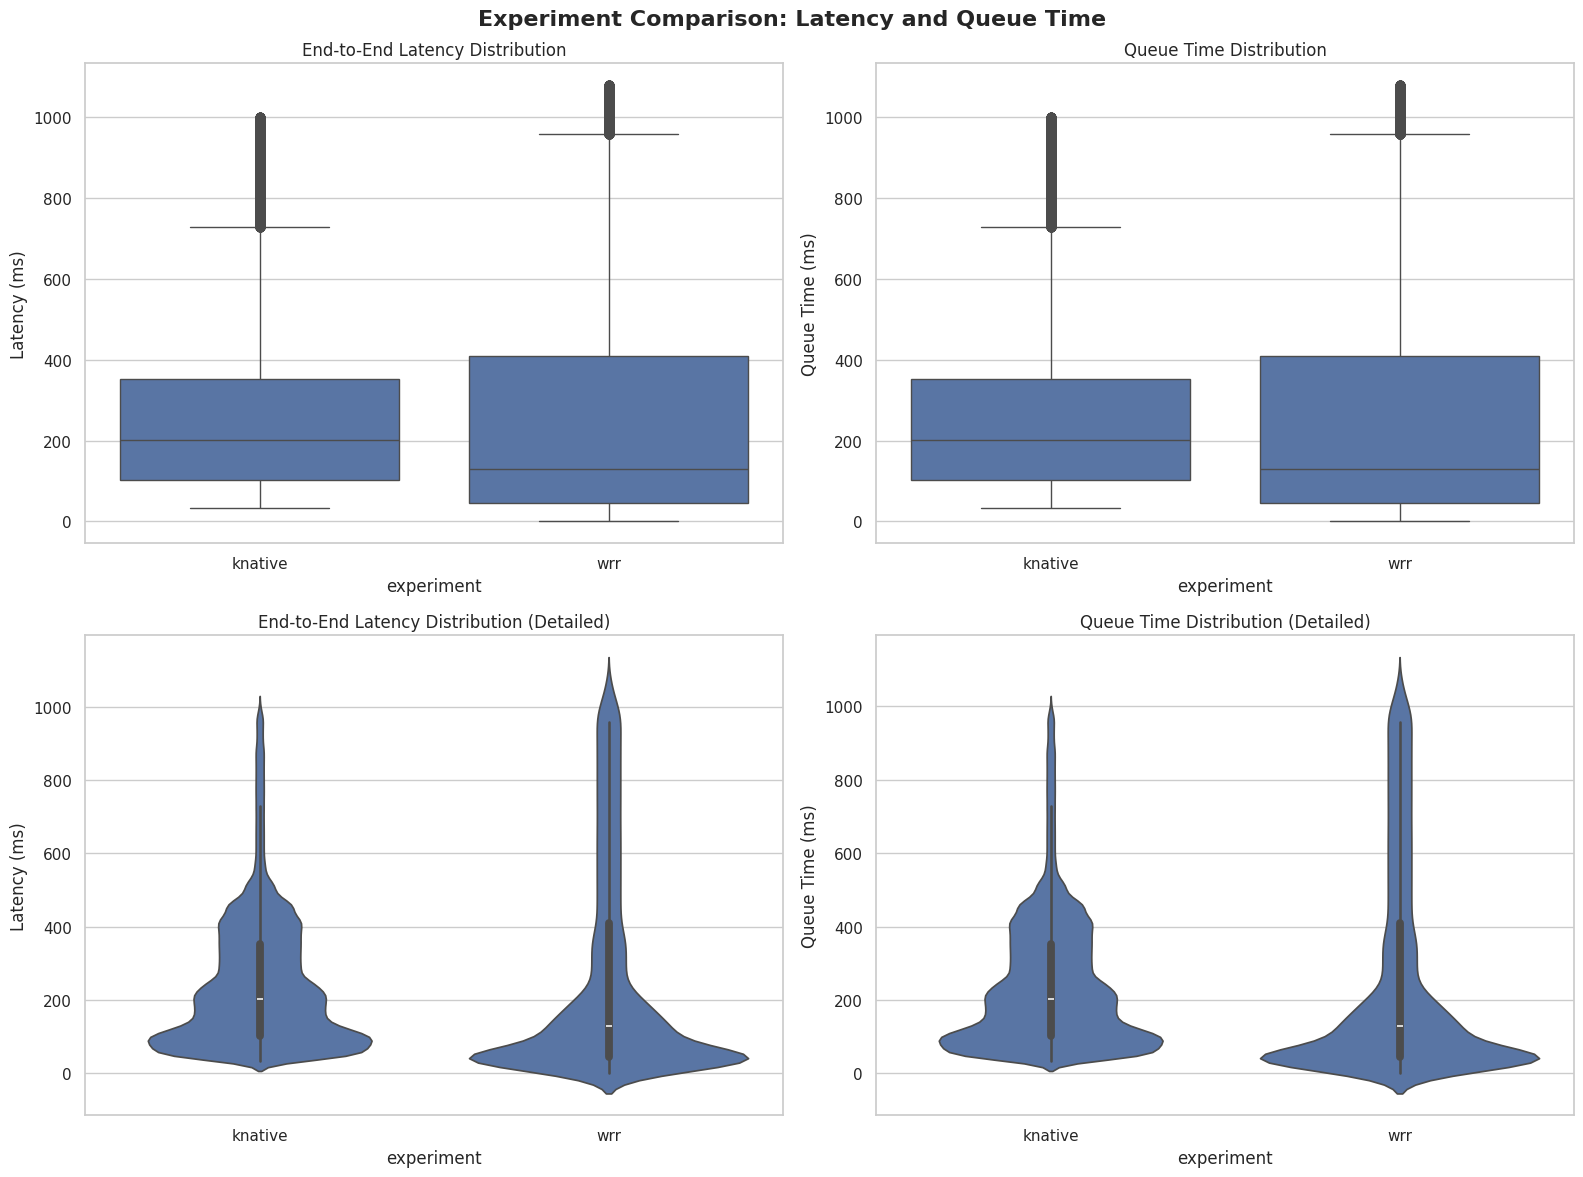


3. PERFORMANCE IMPROVEMENT ANALYSIS
----------------------------------------
Latency improvement (wrr vs knative): -7.12%
Queue time improvement (wrr vs knative): -7.11%

4. LATENCY BREAKDOWN COMPARISON
----------------------------------------

Scheduling Latency:
               mean       std
experiment                   
knative     0.00000  0.000000
wrr         0.00847  0.069431

Arrival Latency:
                  mean         std
experiment                        
knative     247.901813  184.182645
wrr         265.531639  291.901439

Start Latency:
                mean       std
experiment                    
knative     0.000205  0.030701
wrr         0.000303  0.037286

Processing Latency:
                mean       std
experiment                    
knative     0.070370  0.052946
wrr         0.099916  0.067998


In [7]:
# Compare experiments by latency and queue_time
print("="*80)
print("EXPERIMENT COMPARISON: LATENCY AND QUEUE TIME")
print("="*80)

# Extract task data from both experiments
knative_tasks = experiment_data['knative']['task_df']
lowest_time_tasks = experiment_data['wrr']['task_df']

# Add experiment labels
knative_tasks_labeled = knative_tasks.copy()
knative_tasks_labeled['experiment'] = 'knative'
lowest_time_tasks_labeled = lowest_time_tasks.copy()
lowest_time_tasks_labeled['experiment'] = 'wrr'

# Combine for comparison
combined_tasks = pd.concat([knative_tasks_labeled, lowest_time_tasks_labeled], ignore_index=True)

# Statistical comparison
print("\n1. LATENCY COMPARISON")
print("-"*40)
latency_comparison = combined_tasks.groupby('experiment')['end_to_end_latency'].agg(['count', 'mean', 'std', 'min', 'max', 'median'])
print(latency_comparison)

print("\n2. QUEUE TIME COMPARISON")
print("-"*40)
queue_time_comparison = combined_tasks.groupby('experiment')['queue_time'].agg(['count', 'mean', 'std', 'min', 'max', 'median'])
print(queue_time_comparison)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Experiment Comparison: Latency and Queue Time', fontsize=16, fontweight='bold')

# 1. End-to-end latency comparison (boxplot)
ax1 = axes[0, 0]
sns.boxplot(data=combined_tasks, x='experiment', y='end_to_end_latency', ax=ax1)
ax1.set_title('End-to-End Latency Distribution')
ax1.set_ylabel('Latency (ms)')

# 2. Queue time comparison (boxplot)
ax2 = axes[0, 1]
sns.boxplot(data=combined_tasks, x='experiment', y='queue_time', ax=ax2)
ax2.set_title('Queue Time Distribution')
ax2.set_ylabel('Queue Time (ms)')

# 3. End-to-end latency comparison (violin plot)
ax3 = axes[1, 0]
sns.violinplot(data=combined_tasks, x='experiment', y='end_to_end_latency', ax=ax3)
ax3.set_title('End-to-End Latency Distribution (Detailed)')
ax3.set_ylabel('Latency (ms)')

# 4. Queue time comparison (violin plot)
ax4 = axes[1, 1]
sns.violinplot(data=combined_tasks, x='experiment', y='queue_time', ax=ax4)
ax4.set_title('Queue Time Distribution (Detailed)')
ax4.set_ylabel('Queue Time (ms)')

plt.tight_layout()
plt.show()

# Performance improvement analysis
print("\n3. PERFORMANCE IMPROVEMENT ANALYSIS")
print("-"*40)
knative_avg_latency = latency_comparison.loc['knative', 'mean']
lowest_time_avg_latency = latency_comparison.loc['wrr', 'mean']
latency_improvement = ((knative_avg_latency - lowest_time_avg_latency) / knative_avg_latency) * 100

knative_avg_queue = queue_time_comparison.loc['knative', 'mean']
lowest_time_avg_queue = queue_time_comparison.loc['wrr', 'mean']
queue_improvement = ((knative_avg_queue - lowest_time_avg_queue) / knative_avg_queue) * 100

print(f"Latency improvement (wrr vs knative): {latency_improvement:.2f}%")
print(f"Queue time improvement (wrr vs knative): {queue_improvement:.2f}%")

# Additional latency breakdown comparison
print("\n4. LATENCY BREAKDOWN COMPARISON")
print("-"*40)
latency_components = ['scheduling_latency', 'arrival_latency', 'start_latency', 'processing_latency']
for component in latency_components:
    if component in combined_tasks.columns:
        component_stats = combined_tasks.groupby('experiment')[component].agg(['mean', 'std'])
        print(f"\n{component.replace('_', ' ').title()}:")
        print(component_stats)

# Nodes

                  count        mean         std        min         25%  \
execution_node                                                           
node0           17696.0  547.898877  272.824387  79.075980  312.084772   
node1           18063.0  574.284665  280.944732  79.117008  331.845398   
node2           17478.0  550.837951  272.353309  79.063332  315.229926   
node3           17288.0  116.629941  124.548258   0.045011   10.170937   
node4           17264.0   67.814496   50.852356   0.154037   28.001950   
node5           17081.0   74.596859   27.911077  37.493798   54.155642   
node6           17119.0   77.984621   56.156351  11.210430   34.152685   
node7           17347.0   87.654180   63.541365  22.833594   37.601711   

                       50%         75%          max  
execution_node                                       
node0           546.248414  782.572302  1048.137184  
node1           574.177187  816.442978  1079.901365  
node2           551.371520  786.459356  103

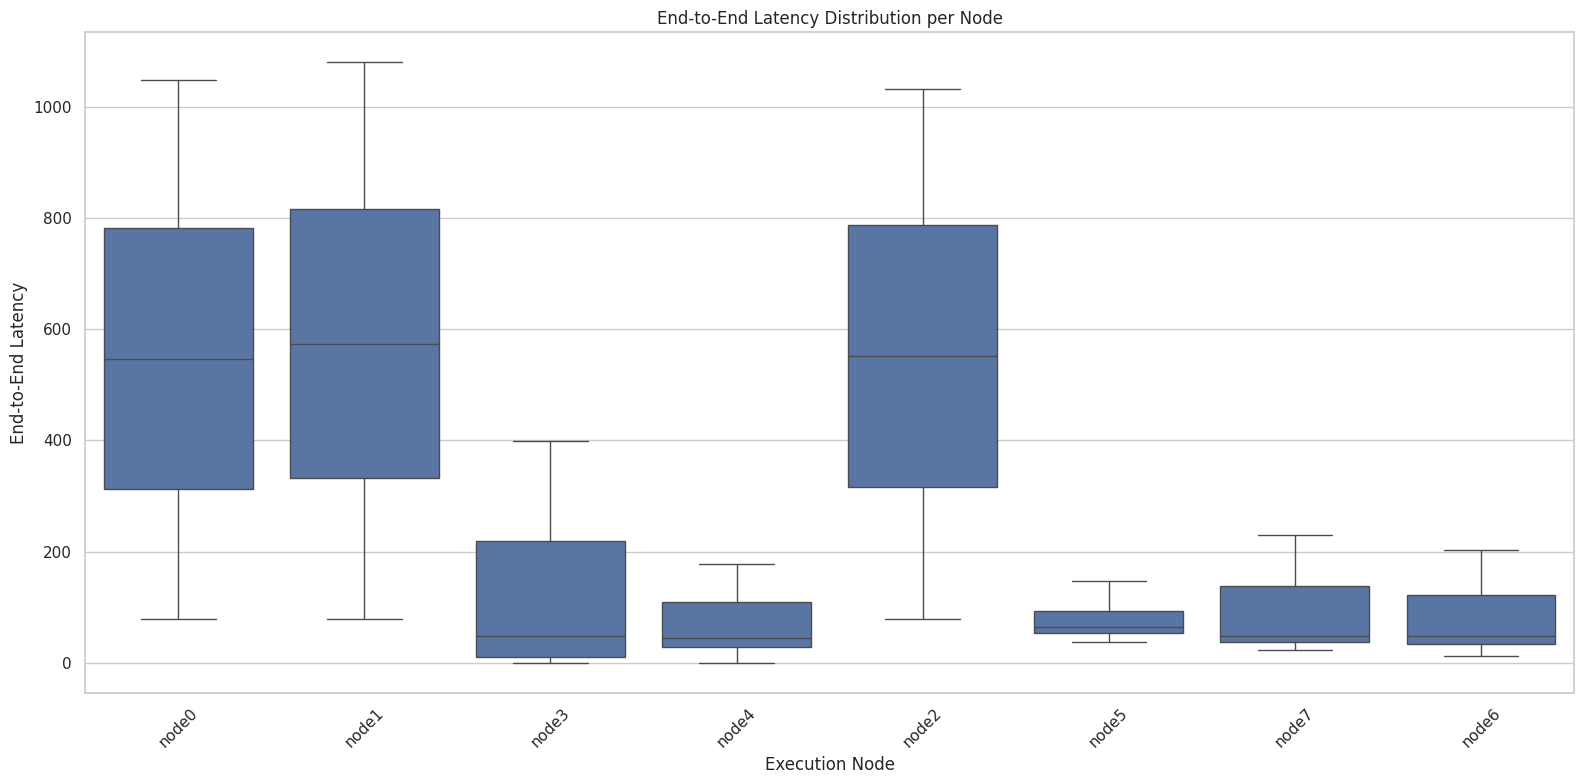

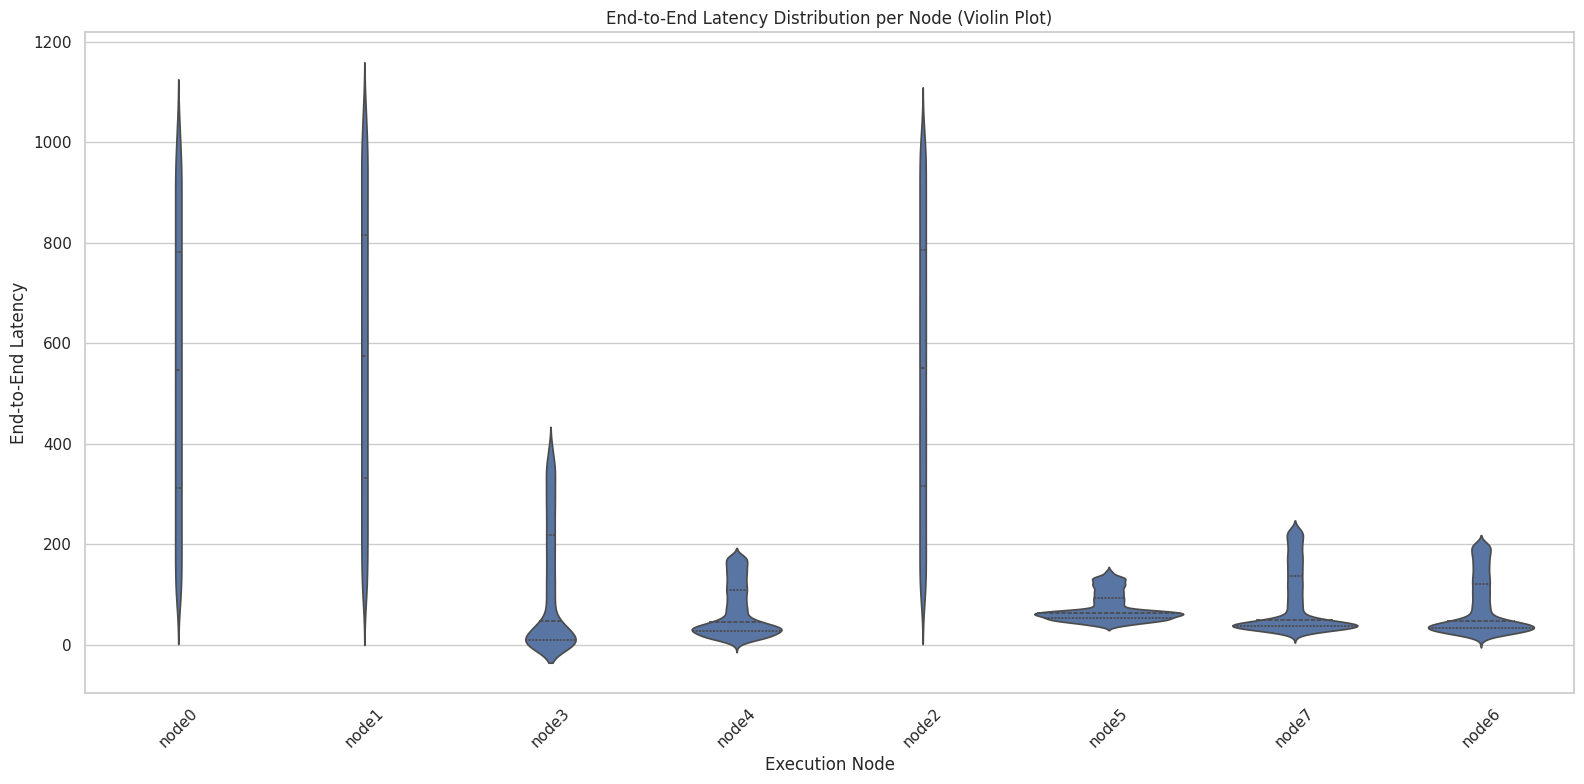

In [8]:
# Analyze and visualize end_to_end_latency for each node
import seaborn as sns
import matplotlib.pyplot as plt

# Group by execution_node and compute statistics
latency_stats = task_df.groupby('execution_node')['end_to_end_latency'].describe()
print(latency_stats)

# Boxplot of end_to_end_latency per node
plt.figure(figsize=(16, 8))
sns.boxplot(data=task_df, x='execution_node', y='end_to_end_latency')
plt.title('End-to-End Latency Distribution per Node')
plt.xlabel('Execution Node')
plt.ylabel('End-to-End Latency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Violin plot for more detail
plt.figure(figsize=(16, 8))
sns.violinplot(data=task_df, x='execution_node', y='end_to_end_latency', inner='quartile')
plt.title('End-to-End Latency Distribution per Node (Violin Plot)')
plt.xlabel('Execution Node')
plt.ylabel('End-to-End Latency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

COMPREHENSIVE NODE ANALYSIS

1. BASIC NODE STATISTICS
----------------------------------------
Total nodes: 10
Total node records: 10
Simulation files: 1

2. NODE UTILIZATION ANALYSIS
----------------------------------------
Unused nodes: 2 (20.0%)
Used nodes: 8 (80.0%)

3. NODE PERFORMANCE METRICS
----------------------------------------
       scheduling_time  storage_time  local_dependencies  cache_hits
count        10.000000     10.000000            10.00000        10.0
mean          1.741404    613.101502         13933.60000         0.0
std           1.104782    366.938068          7349.28984         0.0
min           0.000000      0.000000             0.00000         0.0
25%           1.430266    626.445262         17090.50000         0.0
50%           1.877851    667.802334         17276.00000         0.0
75%           2.442966    762.823544         17445.25000         0.0
max           3.396281   1223.966424         18063.00000         0.0

4. NODE ENERGY ANALYSIS
-------------

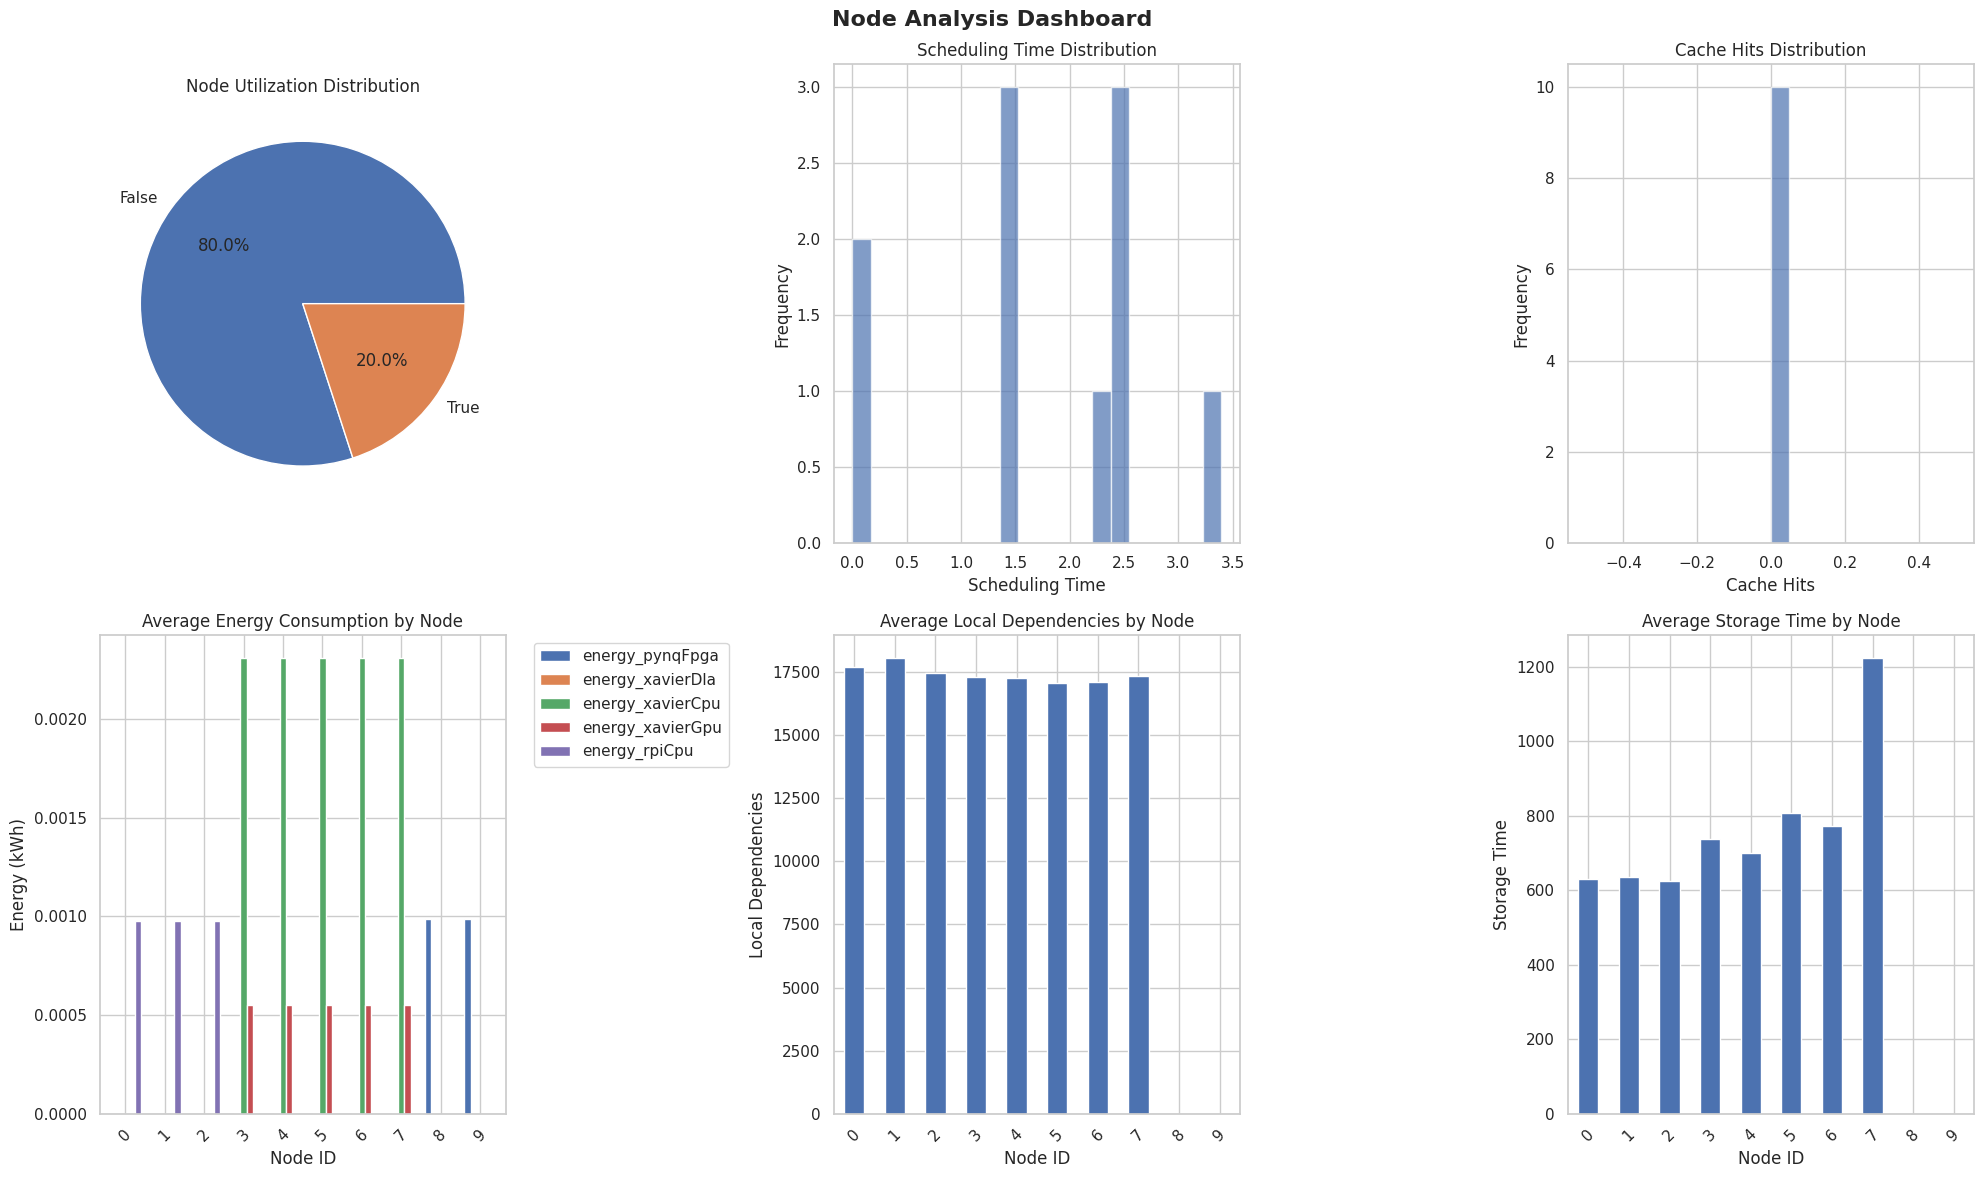


6. CROSS-SIMULATION NODE COMPARISON
----------------------------------------
                           scheduling_time  storage_time  local_dependencies  \
file              node_id                                                      
simulation_1.json 0                 2.3140      629.3679             17696.0   
                  1                 2.5219      635.9283             18063.0   
                  2                 2.4499      625.4710             17478.0   
                  3                 1.4417      737.4879             17288.0   
                  4                 2.4221      699.6764             17264.0   
                  5                 3.3963      807.8483             17081.0   
                  6                 1.4265      771.2688             17119.0   
                  7                 1.4416     1223.9664             17347.0   
                  8                 0.0000        0.0000                 0.0   
                  9                 0.0000

In [9]:
# Comprehensive Node Analysis
print("="*80)
print("COMPREHENSIVE NODE ANALYSIS")
print("="*80)

if not node_df.empty:
    # Basic node statistics
    print("\n1. BASIC NODE STATISTICS")
    print("-"*40)
    print(f"Total nodes: {node_df['node_id'].nunique()}")
    print(f"Total node records: {len(node_df)}")
    print(f"Simulation files: {node_df['file'].nunique()}")
    
    # Node utilization analysis
    print("\n2. NODE UTILIZATION ANALYSIS")
    print("-"*40)
    unused_nodes = node_df[node_df['unused'] == True]
    used_nodes = node_df[node_df['unused'] == False]
    print(f"Unused nodes: {len(unused_nodes)} ({len(unused_nodes)/len(node_df)*100:.1f}%)")
    print(f"Used nodes: {len(used_nodes)} ({len(used_nodes)/len(node_df)*100:.1f}%)")
    
    # Node performance metrics
    print("\n3. NODE PERFORMANCE METRICS")
    print("-"*40)
    performance_cols = ['scheduling_time', 'storage_time', 'local_dependencies', 'cache_hits']
    print(node_df[performance_cols].describe())
    
    # Energy analysis
    print("\n4. NODE ENERGY ANALYSIS")
    print("-"*40)
    energy_cols = [col for col in node_df.columns if col.startswith('energy_')]
    if energy_cols:
        print("Energy consumption by platform type:")
        for col in energy_cols:
            platform_type = col.replace('energy_', '')
            print(f"  {platform_type}: {node_df[col].mean():.4f} kWh (std: {node_df[col].std():.4f})")
    else:
        print("No energy data available")
    
    # Idle time analysis
    print("\n5. NODE IDLE TIME ANALYSIS")
    print("-"*40)
    idle_cols = [col for col in node_df.columns if col.startswith('idle_time_')]
    if idle_cols:
        print("Idle time by platform type:")
        for col in idle_cols:
            platform_type = col.replace('idle_time_', '')
            print(f"  {platform_type}: {node_df[col].mean():.2f}s (std: {node_df[col].std():.2f})")
    else:
        print("No idle time data available")
    
    # Create node analysis visualizations
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Node Analysis Dashboard', fontsize=16, fontweight='bold')
    
    # 1. Node utilization distribution
    ax1 = axes[0, 0]
    node_df['unused'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax1)
    ax1.set_title('Node Utilization Distribution')
    ax1.set_ylabel('')
    
    # 2. Scheduling time distribution
    ax2 = axes[0, 1]
    node_df['scheduling_time'].hist(bins=20, alpha=0.7, ax=ax2)
    ax2.set_title('Scheduling Time Distribution')
    ax2.set_xlabel('Scheduling Time')
    ax2.set_ylabel('Frequency')
    
    # 3. Cache hits distribution
    ax3 = axes[0, 2]
    node_df['cache_hits'].hist(bins=20, alpha=0.7, ax=ax3)
    ax3.set_title('Cache Hits Distribution')
    ax3.set_xlabel('Cache Hits')
    ax3.set_ylabel('Frequency')
    
    # 4. Energy consumption by node
    ax4 = axes[1, 0]
    if energy_cols:
        energy_by_node = node_df.groupby('node_id')[energy_cols].mean()
        energy_by_node.plot(kind='bar', ax=ax4, width=0.8)
        ax4.set_title('Average Energy Consumption by Node')
        ax4.set_xlabel('Node ID')
        ax4.set_ylabel('Energy (kWh)')
        ax4.tick_params(axis='x', rotation=45)
        ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 5. Local dependencies by node
    ax5 = axes[1, 1]
    node_df.groupby('node_id')['local_dependencies'].mean().plot(kind='bar', ax=ax5)
    ax5.set_title('Average Local Dependencies by Node')
    ax5.set_xlabel('Node ID')
    ax5.set_ylabel('Local Dependencies')
    ax5.tick_params(axis='x', rotation=45)
    
    # 6. Storage time by node
    ax6 = axes[1, 2]
    node_df.groupby('node_id')['storage_time'].mean().plot(kind='bar', ax=ax6)
    ax6.set_title('Average Storage Time by Node')
    ax6.set_xlabel('Node ID')
    ax6.set_ylabel('Storage Time')
    ax6.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Cross-simulation node comparison
    print("\n6. CROSS-SIMULATION NODE COMPARISON")
    print("-"*40)
    node_comparison = node_df.groupby(['file', 'node_id']).agg({
        'scheduling_time': 'mean',
        'storage_time': 'mean',
        'local_dependencies': 'mean',
        'cache_hits': 'mean'
    }).round(4)
    print(node_comparison)
    
else:
    print("No node data available for analysis.")

# Platforms

COMPREHENSIVE PLATFORM ANALYSIS

1. BASIC PLATFORM STATISTICS
----------------------------------------
Total platforms: 64
Total platform records: 64
Platform types: 5
Hardware types: 4

2. PLATFORM TYPE DISTRIBUTION
----------------------------------------
platform_type
xavierCpu    40
rpiCpu       12
xavierDla     5
xavierGpu     5
pynqFpga      2
Name: count, dtype: int64

3. HARDWARE TYPE DISTRIBUTION
----------------------------------------
platform_hardware
cpu     52
dla      5
gpu      5
fpga     2
Name: count, dtype: int64

4. PLATFORM PERFORMANCE METRICS
----------------------------------------
          energy  energy_idle    idle_time  idle_proportion  storage_time
count  64.000000    64.000000    64.000000        64.000000     64.000000
mean    0.000300     0.000265  1147.939145        86.774245     95.797110
std     0.000167     0.000179   278.744837        21.070693     59.646182
min     0.000002     0.000002   537.429865        40.625037      0.000000
25%     0.000244  

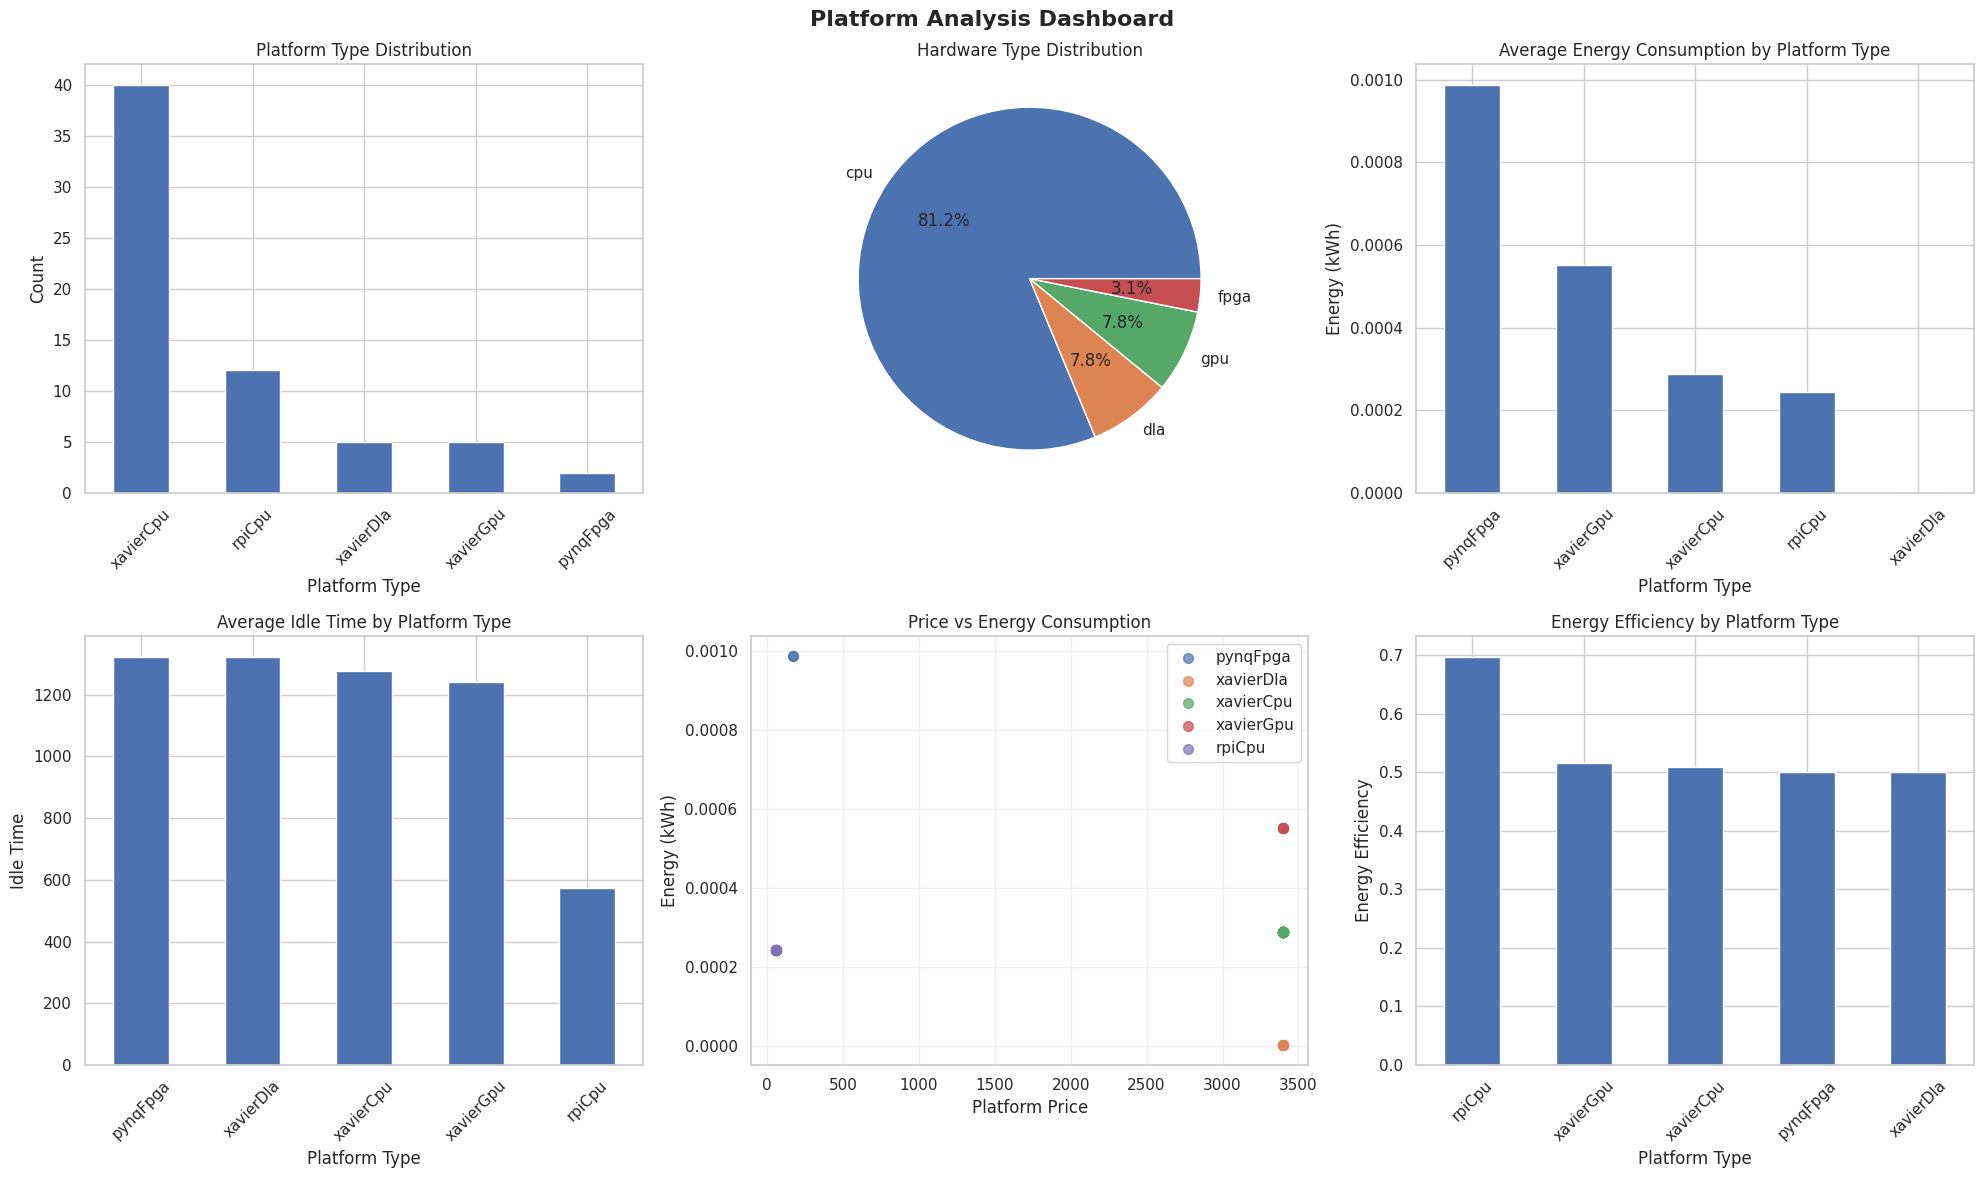


7. PLATFORM UTILIZATION ANALYSIS
----------------------------------------
              idle_proportion          energy energy_idle
                         mean     std    mean        mean
platform_type                                            
pynqFpga             100.0000  0.0000  0.0010      0.0010
rpiCpu                43.4715  1.9652  0.0002      0.0001
xavierCpu             96.5779  1.3251  0.0003      0.0003
xavierDla            100.0000  0.0000  0.0000      0.0000
xavierGpu             93.7554  3.3640  0.0006      0.0005

8. CROSS-SIMULATION PLATFORM COMPARISON
----------------------------------------
                                 energy  idle_time  idle_proportion
file              platform_type                                    
simulation_1.json pynqFpga       0.0010  1322.9031         100.0000
                  rpiCpu         0.0002   575.0858          43.4715
                  xavierCpu      0.0003  1277.6323          96.5779
                  xavierDla      0.0000

In [10]:
# Comprehensive Platform Analysis
print("="*80)
print("COMPREHENSIVE PLATFORM ANALYSIS")
print("="*80)

if not plat_df.empty:
    # Basic platform statistics
    print("\n1. BASIC PLATFORM STATISTICS")
    print("-"*40)
    print(f"Total platforms: {plat_df['platform_id'].nunique()}")
    print(f"Total platform records: {len(plat_df)}")
    print(f"Platform types: {plat_df['platform_type'].nunique()}")
    print(f"Hardware types: {plat_df['platform_hardware'].nunique()}")
    
    # Platform type distribution
    print("\n2. PLATFORM TYPE DISTRIBUTION")
    print("-"*40)
    platform_dist = plat_df['platform_type'].value_counts()
    print(platform_dist)
    
    # Hardware type distribution
    print("\n3. HARDWARE TYPE DISTRIBUTION")
    print("-"*40)
    hardware_dist = plat_df['platform_hardware'].value_counts()
    print(hardware_dist)
    
    # Platform performance metrics
    print("\n4. PLATFORM PERFORMANCE METRICS")
    print("-"*40)
    perf_cols = ['energy', 'energy_idle', 'idle_time', 'idle_proportion', 'storage_time']
    print(plat_df[perf_cols].describe())
    
    # Price analysis
    print("\n5. PLATFORM PRICE ANALYSIS")
    print("-"*40)
    price_stats = plat_df.groupby('platform_type')['platform_price'].agg(['mean', 'std', 'min', 'max'])
    print(price_stats)
    
    # Energy efficiency analysis
    print("\n6. ENERGY EFFICIENCY ANALYSIS")
    print("-"*40)
    plat_df['energy_efficiency'] = plat_df['energy'] / (plat_df['energy'] + plat_df['energy_idle'])
    efficiency_by_type = plat_df.groupby('platform_type')['energy_efficiency'].mean().sort_values(ascending=False)
    print("Energy efficiency by platform type (higher is better):")
    print(efficiency_by_type)
    
    # Create platform analysis visualizations
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Platform Analysis Dashboard', fontsize=16, fontweight='bold')
    
    # 1. Platform type distribution
    ax1 = axes[0, 0]
    platform_dist.plot(kind='bar', ax=ax1)
    ax1.set_title('Platform Type Distribution')
    ax1.set_xlabel('Platform Type')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. Hardware type distribution
    ax2 = axes[0, 1]
    hardware_dist.plot(kind='pie', autopct='%1.1f%%', ax=ax2)
    ax2.set_title('Hardware Type Distribution')
    ax2.set_ylabel('')
    
    # 3. Energy consumption by platform type
    ax3 = axes[0, 2]
    energy_by_type = plat_df.groupby('platform_type')['energy'].mean().sort_values(ascending=False)
    energy_by_type.plot(kind='bar', ax=ax3)
    ax3.set_title('Average Energy Consumption by Platform Type')
    ax3.set_xlabel('Platform Type')
    ax3.set_ylabel('Energy (kWh)')
    ax3.tick_params(axis='x', rotation=45)
    
    # 4. Idle time by platform type
    ax4 = axes[1, 0]
    idle_by_type = plat_df.groupby('platform_type')['idle_time'].mean().sort_values(ascending=False)
    idle_by_type.plot(kind='bar', ax=ax4)
    ax4.set_title('Average Idle Time by Platform Type')
    ax4.set_xlabel('Platform Type')
    ax4.set_ylabel('Idle Time')
    ax4.tick_params(axis='x', rotation=45)
    
    # 5. Price vs Energy scatter plot
    ax5 = axes[1, 1]
    for platform_type in plat_df['platform_type'].unique():
        platform_data = plat_df[plat_df['platform_type'] == platform_type]
        ax5.scatter(platform_data['platform_price'], platform_data['energy'], 
                   label=platform_type, alpha=0.7, s=50)
    ax5.set_title('Price vs Energy Consumption')
    ax5.set_xlabel('Platform Price')
    ax5.set_ylabel('Energy (kWh)')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. Energy efficiency by platform type
    ax6 = axes[1, 2]
    efficiency_by_type.plot(kind='bar', ax=ax6)
    ax6.set_title('Energy Efficiency by Platform Type')
    ax6.set_xlabel('Platform Type')
    ax6.set_ylabel('Energy Efficiency')
    ax6.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Platform utilization analysis
    print("\n7. PLATFORM UTILIZATION ANALYSIS")
    print("-"*40)
    utilization_stats = plat_df.groupby('platform_type').agg({
        'idle_proportion': ['mean', 'std'],
        'energy': 'mean',
        'energy_idle': 'mean'
    }).round(4)
    print(utilization_stats)
    
    # Cross-simulation platform comparison
    print("\n8. CROSS-SIMULATION PLATFORM COMPARISON")
    print("-"*40)
    platform_comparison = plat_df.groupby(['file', 'platform_type']).agg({
        'energy': 'mean',
        'idle_time': 'mean',
        'idle_proportion': 'mean'
    }).round(4)
    print(platform_comparison)
    
else:
    print("No platform data available for analysis.")

# Tasks

COMPREHENSIVE TASK ANALYSIS

1. BASIC TASK STATISTICS
----------------------------------------
Total tasks: 139336
Unique task IDs: 139336
Task types: 2
Platform types used: 3
Hardware types used: 2
Source nodes: 5
Execution nodes: 8

2. TASK TYPE DISTRIBUTION
----------------------------------------
task_type
dnn2    69759
dnn1    69577
Name: count, dtype: int64

3. PLATFORM USAGE BY TASK TYPE
----------------------------------------
platform_type  rpiCpu  xavierCpu  xavierGpu
task_type                                  
dnn1            26559      38133       4885
dnn2            26678      37418       5663

4. TASK PERFORMANCE METRICS
----------------------------------------
        elapsed_time      pull_time  cold_start_time  execution_time  \
count  139336.000000  139336.000000    139336.000000   139336.000000   
mean      265.640328       0.024609         0.000303        0.080062   
std       291.956002       1.251483         0.037286        0.069552   
min         0.045011       

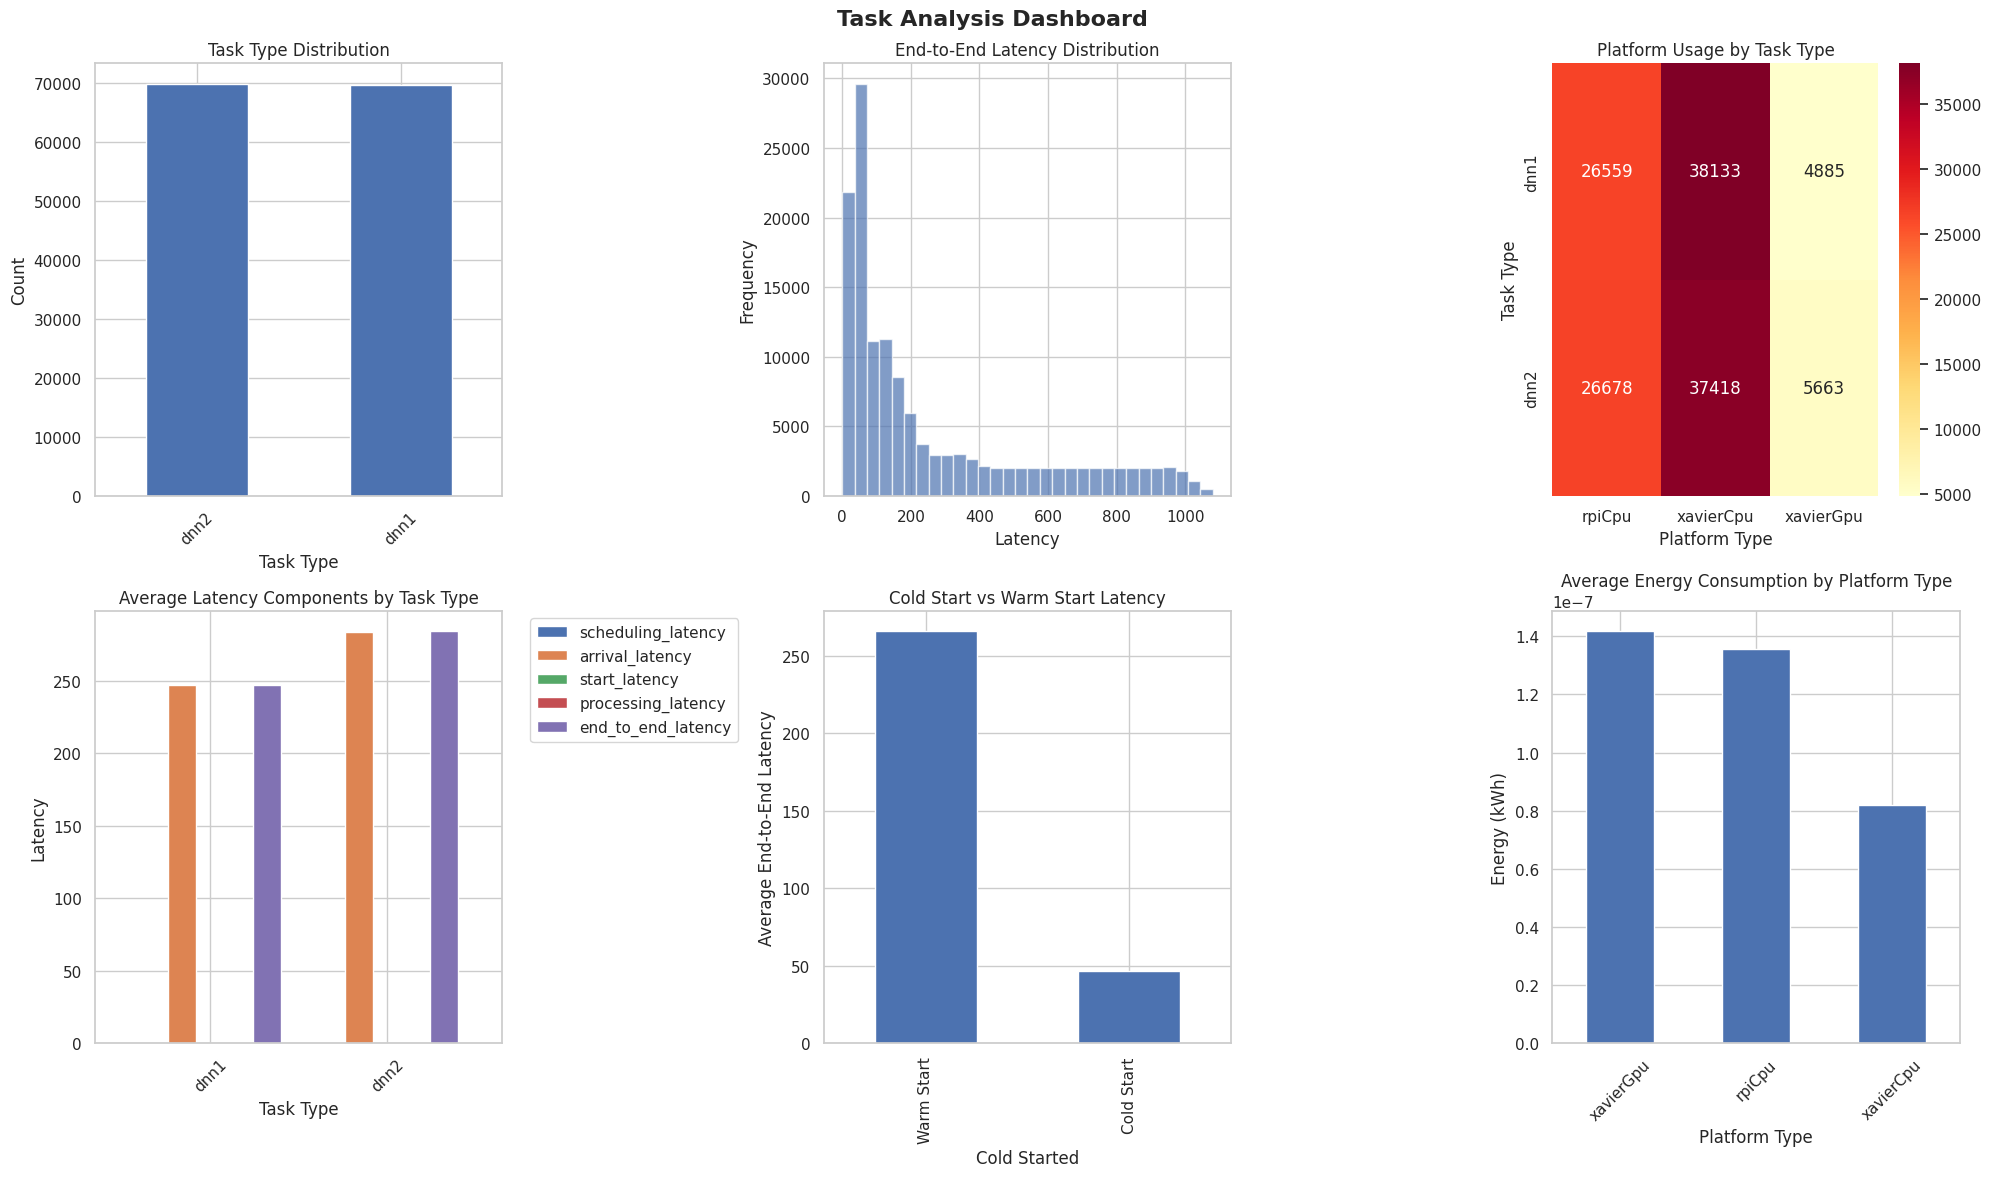


8. TASK EXECUTION PATTERNS
----------------------------------------
Execution node distribution:
execution_node
node1    18063
node0    17696
node2    17478
node7    17347
node3    17288
node4    17264
node6    17119
node5    17081
Name: count, dtype: int64

Source vs Execution Node Analysis:
execution_node  node0  node1  node2  node3  node4  node5  node6  node7
source_node                                                           
node0            3786   3864   3545   3438   3498   3476   3494   3493
node1            3405   3435   3497   3420   3427   3405   3321   3270
node2            3660   3647   3579   3577   3467   3513   3523   3623
node3            3348   3447   3289   3448   3433   3342   3297   3386
node4            3497   3670   3568   3405   3439   3345   3484   3575

9. CROSS-SIMULATION TASK COMPARISON
----------------------------------------
                            end_to_end_latency           energy  \
                                          mean       std   mean

In [11]:
# Comprehensive Task Analysis
print("="*80)
print("COMPREHENSIVE TASK ANALYSIS")
print("="*80)

if not task_df.empty:
    # Basic task statistics
    print("\n1. BASIC TASK STATISTICS")
    print("-"*40)
    print(f"Total tasks: {len(task_df)}")
    print(f"Unique task IDs: {task_df['task_id'].nunique()}")
    print(f"Task types: {task_df['task_type'].nunique()}")
    print(f"Platform types used: {task_df['platform_type'].nunique()}")
    print(f"Hardware types used: {task_df['platform_hardware'].nunique()}")
    print(f"Source nodes: {task_df['source_node'].nunique()}")
    print(f"Execution nodes: {task_df['execution_node'].nunique()}")
    
    # Task type distribution
    print("\n2. TASK TYPE DISTRIBUTION")
    print("-"*40)
    task_type_dist = task_df['task_type'].value_counts()
    print(task_type_dist)
    
    # Platform usage by task type
    print("\n3. PLATFORM USAGE BY TASK TYPE")
    print("-"*40)
    platform_usage = task_df.groupby(['task_type', 'platform_type']).size().unstack(fill_value=0)
    print(platform_usage)
    
    # Task performance metrics
    print("\n4. TASK PERFORMANCE METRICS")
    print("-"*40)
    perf_cols = ['elapsed_time', 'pull_time', 'cold_start_time', 'execution_time', 
                 'wait_time', 'queue_time', 'initialization_time', 'compute_time', 
                 'communications_time', 'network_latency']
    print(task_df[perf_cols].describe())
    
    # Latency analysis
    print("\n5. TASK LATENCY ANALYSIS")
    print("-"*40)
    latency_cols = ['scheduling_latency', 'arrival_latency', 'start_latency', 
                   'processing_latency', 'end_to_end_latency']
    print(task_df[latency_cols].describe())
    
    # Cold start analysis
    print("\n6. COLD START ANALYSIS")
    print("-"*40)
    cold_start_stats = task_df.groupby('cold_started').agg({
        'cold_start_time': 'mean',
        'execution_time': 'mean',
        'end_to_end_latency': 'mean'
    }).round(4)
    print(cold_start_stats)
    
    # Cache hit analysis
    print("\n7. CACHE HIT ANALYSIS")
    print("-"*40)
    cache_stats = task_df.groupby('cache_hit').agg({
        'pull_time': 'mean',
        'execution_time': 'mean',
        'end_to_end_latency': 'mean'
    }).round(4)
    print(cache_stats)
    
    # Create task analysis visualizations
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Task Analysis Dashboard', fontsize=16, fontweight='bold')
    
    # 1. Task type distribution
    ax1 = axes[0, 0]
    task_type_dist.plot(kind='bar', ax=ax1)
    ax1.set_title('Task Type Distribution')
    ax1.set_xlabel('Task Type')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. End-to-end latency distribution
    ax2 = axes[0, 1]
    task_df['end_to_end_latency'].hist(bins=30, alpha=0.7, ax=ax2)
    ax2.set_title('End-to-End Latency Distribution')
    ax2.set_xlabel('Latency')
    ax2.set_ylabel('Frequency')
    
    # 3. Platform usage heatmap
    ax3 = axes[0, 2]
    sns.heatmap(platform_usage, annot=True, fmt='d', cmap='YlOrRd', ax=ax3)
    ax3.set_title('Platform Usage by Task Type')
    ax3.set_xlabel('Platform Type')
    ax3.set_ylabel('Task Type')
    
    # 4. Latency components by task type
    ax4 = axes[1, 0]
    latency_by_task = task_df.groupby('task_type')[latency_cols].mean()
    latency_by_task.plot(kind='bar', ax=ax4, width=0.8)
    ax4.set_title('Average Latency Components by Task Type')
    ax4.set_xlabel('Task Type')
    ax4.set_ylabel('Latency')
    ax4.tick_params(axis='x', rotation=45)
    ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 5. Cold start vs warm start comparison
    ax5 = axes[1, 1]
    cold_warm_comparison = task_df.groupby('cold_started')['end_to_end_latency'].mean()
    cold_warm_comparison.plot(kind='bar', ax=ax5)
    ax5.set_title('Cold Start vs Warm Start Latency')
    ax5.set_xlabel('Cold Started')
    ax5.set_ylabel('Average End-to-End Latency')
    ax5.set_xticklabels(['Warm Start', 'Cold Start'])
    
    # 6. Energy consumption by platform type
    ax6 = axes[1, 2]
    energy_by_platform = task_df.groupby('platform_type')['energy'].mean().sort_values(ascending=False)
    energy_by_platform.plot(kind='bar', ax=ax6)
    ax6.set_title('Average Energy Consumption by Platform Type')
    ax6.set_xlabel('Platform Type')
    ax6.set_ylabel('Energy (kWh)')
    ax6.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Task execution patterns
    print("\n8. TASK EXECUTION PATTERNS")
    print("-"*40)
    
    # Execution node distribution
    print("Execution node distribution:")
    exec_node_dist = task_df['execution_node'].value_counts()
    print(exec_node_dist)
    
    # Source vs execution node analysis
    print("\nSource vs Execution Node Analysis:")
    source_exec_analysis = task_df.groupby(['source_node', 'execution_node']).size().unstack(fill_value=0)
    print(source_exec_analysis)
    
    # Cross-simulation task comparison
    print("\n9. CROSS-SIMULATION TASK COMPARISON")
    print("-"*40)
    task_comparison = task_df.groupby(['file', 'task_type']).agg({
        'end_to_end_latency': ['mean', 'std'],
        'energy': 'mean',
        'cold_start_time': 'mean'
    }).round(4)
    print(task_comparison)
    
else:
    print("No task data available for analysis.")

In [29]:
aggregation_window_seconds=10

# Convert timestamps to datetime for time-based analysis
task_df_time = task_df.copy()
task_df_time['dispatched_datetime'] = task_df_time['dispatched_time']
task_df_time['scheduled_datetime'] = task_df_time['scheduled_time']
task_df_time['arrived_datetime'] = task_df_time['arrived_time']
task_df_time['started_datetime'] = task_df_time['started_time']
task_df_time['done_datetime'] = task_df_time['done_time']

# Create time windows
min_time = task_df_time['dispatched_datetime'].min()
max_time = task_df_time['done_datetime'].max()
total_duration = max_time - min_time

print(f"Simulation duration: {total_duration:.2f} seconds")
print(f"Number of {aggregation_window_seconds}s windows: {int(total_duration / aggregation_window_seconds)}")

# Create time bins
time_bins = pd.date_range(start=min_time, end=max_time, freq=f'{aggregation_window_seconds}s')
task_df_time['time_window'] = task_df_time['dispatched_datetime']

task_df_time.head()

Simulation duration: 1322.88 seconds
Number of 10s windows: 132


,experiment,file,task_id,dispatched_time,scheduled_time,arrived_time,started_time,done_time,task_type,platform_type,...,arrival_latency,start_latency,processing_latency,end_to_end_latency,dispatched_datetime,scheduled_datetime,arrived_datetime,started_datetime,done_datetime,time_window
0,wrr,simulation_1.json,0,0.018071,0.865549,78.278491,78.914491,79.100786,dnn1,rpiCpu,...,77.412942,0.636,0.186296,79.082716,0.018071,0.865549,78.278491,78.914491,79.100786,0.018071
1,wrr,simulation_1.json,1,0.035107,0.874902,97.514590,97.514590,97.700886,dnn2,rpiCpu,...,96.639688,0.000,0.186296,97.665779,0.035107,0.874902,97.514590,97.514590,97.700886,0.035107
2,wrr,simulation_1.json,2,0.035362,0.865670,79.219969,79.855969,80.042264,dnn2,rpiCpu,...,78.354299,0.636,0.186296,80.006902,0.035362,0.865670,79.219969,79.855969,80.042264,0.035362
3,wrr,simulation_1.json,3,0.050290,0.865759,80.136264,80.136264,80.322560,dnn2,rpiCpu,...,79.270505,0.000,0.186296,80.272270,0.050290,0.865759,80.136264,80.136264,80.322560,0.050290
4,wrr,simulation_1.json,4,0.055112,0.865845,79.100786,79.100786,79.287082,dnn1,rpiCpu,...,78.234942,0.000,0.186296,79.231970,0.055112,0.865845,79.100786,79.100786,79.287082,0.055112



2. NODE-LEVEL AGGREGATION ANALYSIS
--------------------------------------------------
Node aggregation metrics per time window:
                           end_to_end_latency                                 \
                                        count     mean std      min      max   
time_window execution_node                                                     
0.018071    node0                           1  79.0827 NaN  79.0827  79.0827   
0.035107    node1                           1  97.6658 NaN  97.6658  97.6658   
0.035362    node1                           1  80.0069 NaN  80.0069  80.0069   
0.050290    node1                           1  80.2723 NaN  80.2723  80.2723   
0.055112    node0                           1  79.2320 NaN  79.2320  79.2320   
0.055973    node1                           1  80.5469 NaN  80.5469  80.5469   
0.075626    node1                           1  80.8075 NaN  80.8075  80.8075   
0.081777    node0                           1  79.3916 NaN  79.3916  79

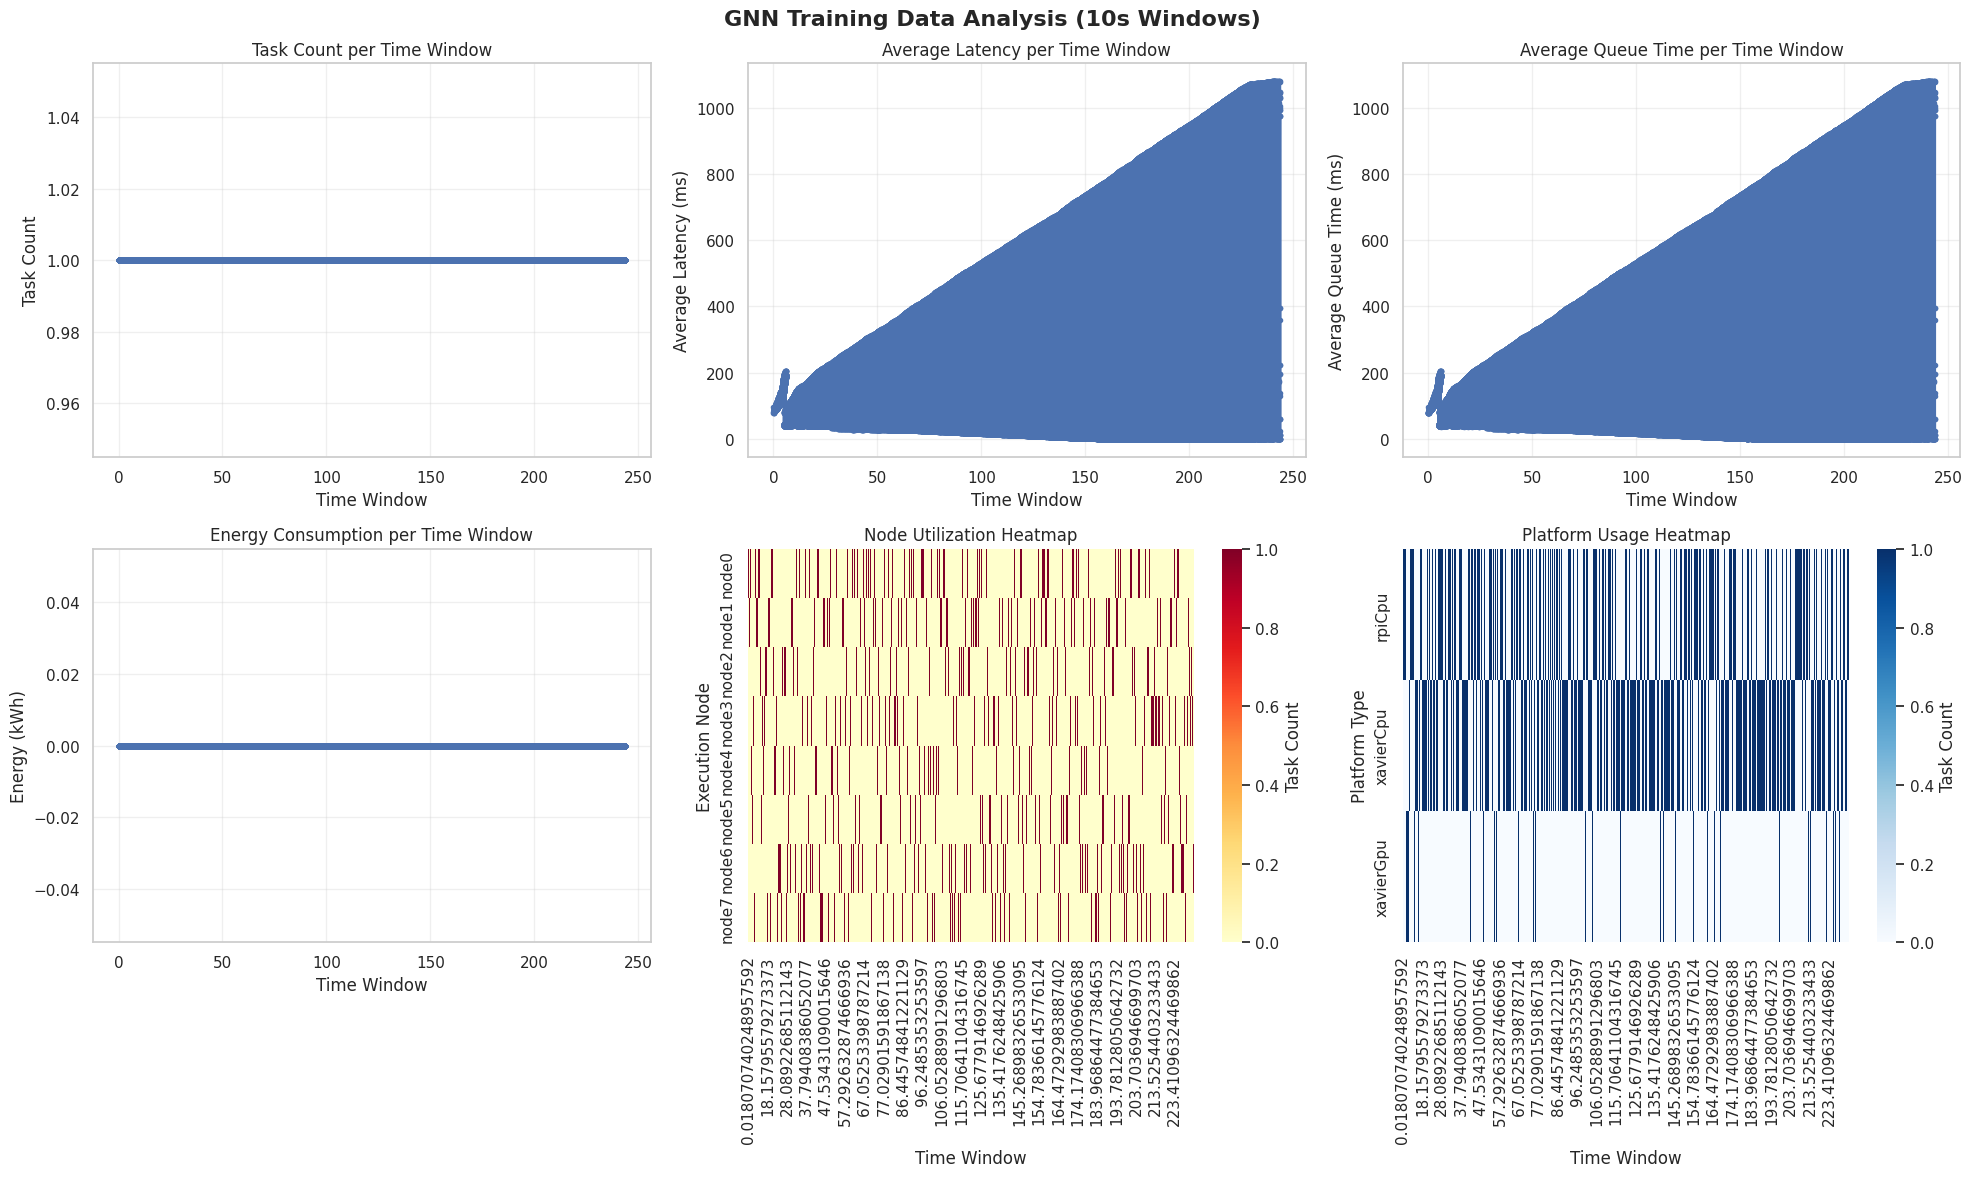


10. GNN TRAINING RECOMMENDATIONS
--------------------------------------------------
Based on the analysis, here are recommendations for GNN training:

A. FEATURE ENGINEERING:
  - Node features: latency_mean, latency_std, queue_mean, queue_std, task_count, cold_start_count, energy_sum
  - Edge features: network_latency, cross_node_communication_patterns
  - Global features: system_load, platform_diversity, task_type_diversity

B. TEMPORAL AGGREGATION:
  - Use 10s windows for feature aggregation
  - Include rolling statistics (mean, std, min, max) over multiple windows
  - Consider exponential moving averages for smooth transitions

C. TRAINING DATA STRUCTURE:
  - Each training sample: (node_features, edge_features, target_weights)
  - Target: optimal node weights for weighted round-robin scheduling
  - Labels: inverse of average latency or queue time per node

D. DATA AUGMENTATION:
  - Use sliding windows to create more training samples
  - Add noise to features for robustness
  - Bala

In [31]:
# 2. Node-level aggregation analysis
print("\n2. NODE-LEVEL AGGREGATION ANALYSIS")
print("-"*50)
node_aggregation = task_df_time.groupby(['time_window', 'execution_node']).agg({
    'end_to_end_latency': ['count', 'mean', 'std', 'min', 'max'],
    'queue_time': ['mean', 'std'],
    'execution_time': ['mean', 'std'],
    'cold_start_time': ['mean', 'sum'],
    'energy': ['sum', 'mean'],
    'cold_started': 'sum',
    'cache_hit': 'sum'
}).round(4)
print("Node aggregation metrics per time window:")
print(node_aggregation.head(20))

# 3. Platform-level aggregation analysis
print("\n3. PLATFORM-LEVEL AGGREGATION ANALYSIS")
print("-"*50)
platform_aggregation = task_df_time.groupby(['time_window', 'platform_type']).agg({
    'end_to_end_latency': ['count', 'mean', 'std'],
    'queue_time': ['mean', 'std'],
    'execution_time': ['mean', 'std'],
    'energy': ['sum', 'mean'],
    'cold_started': 'sum',
    'cache_hit': 'sum'
}).round(4)
print("Platform aggregation metrics per time window:")
print(platform_aggregation.head(20))

# 4. Task-type aggregation analysis
print("\n4. TASK-TYPE AGGREGATION ANALYSIS")
print("-"*50)
task_type_aggregation = task_df_time.groupby(['time_window', 'task_type']).agg({
    'end_to_end_latency': ['count', 'mean', 'std'],
    'queue_time': ['mean', 'std'],
    'execution_time': ['mean', 'std'],
    'energy': ['sum', 'mean'],
    'cold_started': 'sum',
    'cache_hit': 'sum'
}).round(4)
print("Task-type aggregation metrics per time window:")
print(task_type_aggregation.head(20))

# 5. System-wide aggregation analysis
print("\n5. SYSTEM-WIDE AGGREGATION ANALYSIS")
print("-"*50)
system_aggregation = task_df_time.groupby('time_window').agg({
    'end_to_end_latency': ['count', 'mean', 'std'],
    'queue_time': ['mean', 'std'],
    'execution_time': ['mean', 'std'],
    'energy': ['sum', 'mean'],
    'cold_started': 'sum',
    'cache_hit': 'sum',
    'execution_node': 'nunique',
    'platform_type': 'nunique',
    'task_type': 'nunique'
}).round(4)
print("System-wide aggregation metrics per time window:")
print(system_aggregation.head(20))

# 6. Cross-node communication analysis
print("\n6. CROSS-NODE COMMUNICATION ANALYSIS")
print("-"*50)
cross_node_aggregation = task_df_time.groupby(['time_window', 'source_node', 'execution_node']).agg({
    'end_to_end_latency': ['count', 'mean'],
    'network_latency': ['mean', 'std'],
    'energy': 'sum'
}).round(4)
print("Cross-node communication patterns per time window:")
print(cross_node_aggregation.head(20))

# 7. Feature engineering analysis for GNN
print("\n7. FEATURE ENGINEERING ANALYSIS FOR GNN")
print("-"*50)
gnn_features = task_df_time.groupby(['time_window', 'execution_node']).agg({
    'end_to_end_latency': ['mean', 'std', 'min', 'max'],
    'queue_time': ['mean', 'std'],
    'execution_time': ['mean', 'std'],
    'task_id': 'count',
    'cold_started': 'sum',
    'cache_hit': 'sum',
    'energy': ['sum', 'mean'],
    'platform_type': 'nunique',
    'task_type': 'nunique'
}).round(4)
gnn_features.columns = ['_'.join(col).strip() for col in gnn_features.columns]
print("GNN feature engineering per node per time window:")
print(gnn_features.head(20))

# 8. Temporal patterns analysis
print("\n8. TEMPORAL PATTERNS ANALYSIS")
print("-"*50)
temporal_analysis = task_df_time.groupby('time_window').agg({
    'end_to_end_latency': 'mean',
    'queue_time': 'mean',
    'energy': 'sum',
    'task_id': 'count'
}).round(4)
print("Temporal patterns over time windows:")
print(temporal_analysis.head(20))

# 9. Visualization of aggregated data
print("\n9. VISUALIZATION OF AGGREGATED DATA")
print("-"*50)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'GNN Training Data Analysis ({aggregation_window_seconds}s Windows)', fontsize=16, fontweight='bold')

# 1. Task count per time window
ax1 = axes[0, 0]
if len(temporal_analysis) > 0:
    temporal_analysis['task_id'].plot(kind='line', ax=ax1, marker='o', markersize=3)
ax1.set_title('Task Count per Time Window')
ax1.set_xlabel('Time Window')
ax1.set_ylabel('Task Count')
ax1.grid(True, alpha=0.3)

# 2. Average latency per time window
ax2 = axes[0, 1]
if len(temporal_analysis) > 0:
    temporal_analysis['end_to_end_latency'].plot(kind='line', ax=ax2, marker='o', markersize=3)
ax2.set_title('Average Latency per Time Window')
ax2.set_xlabel('Time Window')
ax2.set_ylabel('Average Latency (ms)')
ax2.grid(True, alpha=0.3)

# 3. Average queue time per time window
ax3 = axes[0, 2]
if len(temporal_analysis) > 0:
    temporal_analysis['queue_time'].plot(kind='line', ax=ax3, marker='o', markersize=3)
ax3.set_title('Average Queue Time per Time Window')
ax3.set_xlabel('Time Window')
ax3.set_ylabel('Average Queue Time (ms)')
ax3.grid(True, alpha=0.3)

# 4. Energy consumption per time window
ax4 = axes[1, 0]
if len(temporal_analysis) > 0:
    temporal_analysis['energy'].plot(kind='line', ax=ax4, marker='o', markersize=3)
ax4.set_title('Energy Consumption per Time Window')
ax4.set_xlabel('Time Window')
ax4.set_ylabel('Energy (kWh)')
ax4.grid(True, alpha=0.3)

# 5. Node utilization heatmap
ax5 = axes[1, 1]
try:
    node_utilization = task_df_time.groupby(['time_window', 'execution_node'])['task_id'].count().unstack(fill_value=0)
    if not node_utilization.empty and node_utilization.size > 0:
        sns.heatmap(node_utilization.T, cmap='YlOrRd', ax=ax5, cbar_kws={'label': 'Task Count'})
    else:
        ax5.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax5.transAxes)
except Exception as e:
    ax5.text(0.5, 0.5, f'Error: {str(e)}', ha='center', va='center', transform=ax5.transAxes)
ax5.set_title('Node Utilization Heatmap')
ax5.set_xlabel('Time Window')
ax5.set_ylabel('Execution Node')

# 6. Platform usage heatmap
ax6 = axes[1, 2]
try:
    platform_usage = task_df_time.groupby(['time_window', 'platform_type'])['task_id'].count().unstack(fill_value=0)
    if not platform_usage.empty and platform_usage.size > 0:
        sns.heatmap(platform_usage.T, cmap='Blues', ax=ax6, cbar_kws={'label': 'Task Count'})
    else:
        ax6.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax6.transAxes)
except Exception as e:
    ax6.text(0.5, 0.5, f'Error: {str(e)}', ha='center', va='center', transform=ax6.transAxes)
ax6.set_title('Platform Usage Heatmap')
ax6.set_xlabel('Time Window')
ax6.set_ylabel('Platform Type')

plt.tight_layout()
plt.show()

# 10. GNN training recommendations
print("\n10. GNN TRAINING RECOMMENDATIONS")
print("-"*50)
print("Based on the analysis, here are recommendations for GNN training:\n")
print("A. FEATURE ENGINEERING:")
print("  - Node features: latency_mean, latency_std, queue_mean, queue_std, task_count, cold_start_count, energy_sum")
print("  - Edge features: network_latency, cross_node_communication_patterns")
print("  - Global features: system_load, platform_diversity, task_type_diversity\n")
print("B. TEMPORAL AGGREGATION:")
print(f"  - Use {aggregation_window_seconds}s windows for feature aggregation")
print("  - Include rolling statistics (mean, std, min, max) over multiple windows")
print("  - Consider exponential moving averages for smooth transitions\n")
print("C. TRAINING DATA STRUCTURE:")
print("  - Each training sample: (node_features, edge_features, target_weights)")
print("  - Target: optimal node weights for weighted round-robin scheduling")
print("  - Labels: inverse of average latency or queue time per node\n")
print("D. DATA AUGMENTATION:")
print("  - Use sliding windows to create more training samples")
print("  - Add noise to features for robustness")
print("  - Balance samples across different load conditions\n")
print("E. VALIDATION STRATEGY:")
print("  - Time-based split: train on early windows, validate on later windows")
print("  - Cross-validation across different simulation runs")
print("  - Online evaluation with real-time model updates")

# Analyze with different time windows
# print("ANALYZING WITH 10-SECOND WINDOWS (MATCHING SCHEDULER)")
# print("="*60)
# results_10s = analyze_aggregated_data_for_gnn(task_df, node_df, plat_df, aggregation_window_seconds=10)

# print("\n" + "="*60)
# print("ANALYZING WITH 30-SECOND WINDOWS (FOR COMPARISON)")
# print("="*60)
# results_30s = analyze_aggregated_data_for_gnn(task_df, node_df, plat_df, aggregation_window_seconds=30)

# print("\n" + "="*60)
# print("ANALYZING WITH 60-SECOND WINDOWS (FOR COMPARISON)")
#print("="*60)
# results_60s = analyze_aggregated_data_for_gnn(task_df, node_df, plat_df, aggregation_window_seconds=60)